<a href="https://colab.research.google.com/github/maierav/claupenscope/blob/main/notebooks/stability_snr_multimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Recording stability & SNR-over-time — ecephys / mesoscope / SLAP2

**Question.** For every modality in OpenScope-PP, *what fraction of the signal we record at the start of a session is still usable at the end?* The mechanisms differ — Neuropixels electrodes drift relative to neurons, mesoscope GCaMP photobleaches and the imaging plane can shift in z, SLAP2 iGluSnFR bleaches faster and the DMDs target small dendritic patches that are very sensitive to xy/z drift. The notebook builds one resume-safe cache per dandiset, then renders comparable figures for each modality plus a single cross-modal summary.

**Per-modality measure.**
* **Ecephys (001637).** Bin spike times at 60 s; per unit compute mean rate, fraction of session bins where the rate exceeds 50 % of the unit's median rate (`active_frac`), and the slope of `log10(rate)` over session time.
* **Mesoscope (001768) / SLAP2 (001424).** Stride-read dF/F traces from each imaging plane / DMD, bin to 30 s, compute the mean (z-drift / baseline drift proxy) and the SD across ROIs (shot-noise / bleach proxy). Retention is the SD over the last quartile relative to the first quartile.

**Figures.**
1. Ecephys stability raster — one example session, units sorted by `active_frac` (drift-affected units are visibly time-localised).
2. Ecephys active-unit retention curves — one line per session, coloured by subject.
3. Per-unit `active_frac` distribution, all ecephys sessions pooled.
4. Mesoscope dF/F SD over time per session, normalised to the first 5 min.
5. SLAP2 dF/F SD over time per session × DMD.
6. Cross-modal stability summary — violin per modality of "fraction of signal retained at session end".

All outputs as vector PDF + raster PNG.

In [1]:
!pip install -q git+https://github.com/maierav/claupenscope.git \
    dandi remfile h5py pynwb scipy matplotlib numpy pandas

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.2/386.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.5/85.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import os, time, pickle, gc, glob
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from dandi.dandiapi import DandiAPIClient

from openscope_pp.loaders.streaming import open_nwb
from openscope_pp.loaders.trials import load_trials

mpl.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.family": "serif",
    "font.serif": ["DejaVu Serif", "Liberation Serif", "serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 9.5, "axes.labelsize": 10, "axes.titlesize": 10.5,
    "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "legend.fontsize": 8.0, "legend.frameon": False,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
})

MOD_COLOR = {"ecephys": "#555555", "meso": "#4878CF", "slap2": "#D65F5F"}

ECEPHYS_DS = "001637"
MESO_DS    = "001768"
SLAP2_DS   = "001424"

ECEPHYS_CACHE = "results/stability_cache_ecephys"
MESO_CACHE    = "results/stability_cache_meso"
SLAP2_CACHE   = "results/stability_cache_slap2"
for d in (ECEPHYS_CACHE, MESO_CACHE, SLAP2_CACHE):
    os.makedirs(d, exist_ok=True)

BIN_E_S    = 60.0   # ecephys spike-count bin (s)
BIN_O_S    = 30.0   # imaging time bin (s)
MESO_STRIDE = 30    # frame stride when streaming dF/F
SLAP2_STRIDE = 10
ACTIVE_FRAC_RATE_FRAC = 0.5   # "active" if rate >= this * unit's median rate

# Limit how many uncached sessions per modality this run; None = all.
N_NEW_PER_MODALITY = None
# For SLAP2 always skip the older NWB format subject
SLAP2_SKIP_SUBJECT = "sub-794237"

print("Setup complete.  Caches under results/stability_cache_*/")

Setup complete.  Caches under results/stability_cache_*/


## 1. Ecephys cache — per-unit firing-rate timeline

In [3]:
def decode_str(arr):
    if arr.dtype.kind in ("S", "O"):
        return np.array([v.decode() if isinstance(v, bytes) else str(v) for v in arr])
    return arr

def cache_ecephys(asset, force=False):
    asset_id   = asset.identifier
    subject_id = asset.path.split("/")[0]
    cp = os.path.join(ECEPHYS_CACHE, f"{asset_id[:8]}.pkl")
    if os.path.exists(cp) and not force:
        return cp, "cached"

    t0 = time.time()
    handle = open_nwb(asset_id)
    try:
        h5 = handle.h5
        u  = h5["units"]
        decoder_label = decode_str(u["decoder_label"][:])
        default_qc    = u["default_qc"][:].astype(bool)
        device_name   = decode_str(u["device_name"][:])
        spike_times   = u["spike_times"][:]
        spk_index     = u["spike_times_index"][:]
        depth_um      = (np.asarray(u["depth"][:]).astype(float)
                         if "depth" in u else np.full(len(decoder_label), np.nan))

        is_sua = (decoder_label == "sua") & default_qc
        sua_idx = np.where(is_sua)[0]
        if not len(sua_idx):
            return cp, "skip (no SUA)"

        # Session bounds from spike-time extremes
        t_start = float(spike_times.min())
        t_end   = float(spike_times.max())
        edges = np.arange(t_start, t_end + BIN_E_S, BIN_E_S)
        centers = 0.5 * (edges[:-1] + edges[1:])
        n_bins = len(centers)
        rates = np.zeros((len(sua_idx), n_bins), dtype=np.float32)
        for j, uid in enumerate(sua_idx):
            i0 = int(spk_index[uid - 1]) if uid > 0 else 0
            s  = spike_times[i0:int(spk_index[uid])]
            if not len(s): continue
            cnt, _ = np.histogram(s, bins=edges)
            rates[j, :] = cnt / BIN_E_S

        # Per-unit summary
        med_rate = np.median(rates, axis=1)
        mean_rate = rates.mean(axis=1)
        active_frac = np.mean(rates >= (ACTIVE_FRAC_RATE_FRAC *
                                         np.maximum(med_rate, 0.05))[:, None], axis=1)
        # log-rate slope across session time (excludes silent units)
        log_rate = np.log10(rates + 0.05)
        x = (centers - centers[0]) / max((centers[-1] - centers[0]), 1.0)
        x_centred = x - x.mean()
        denom = float((x_centred ** 2).sum())
        slope = ((log_rate - log_rate.mean(axis=1, keepdims=True)) * x_centred[None, :]).sum(axis=1) / max(denom, 1e-9)
        df = pd.DataFrame({
            "unit_idx": sua_idx,
            "device_name": device_name[sua_idx],
            "depth_um":   depth_um[sua_idx],
            "mean_rate":  mean_rate,
            "median_rate": med_rate,
            "active_frac": active_frac,
            "log_slope":   slope,
        })
        # Retention = mean rate in last quartile / mean rate in first quartile
        q = max(n_bins // 4, 1)
        first_q = rates[:, :q].mean(axis=1)
        last_q  = rates[:, -q:].mean(axis=1)
        df["retention"] = np.where(first_q > 1e-3, last_q / first_q, np.nan)

        meta = {
            "asset_id": asset_id, "subject_id": subject_id,
            "asset_path": asset.path,
            "t_start": t_start, "t_end": t_end,
            "bin_centers": centers,
            "runtime_s": time.time() - t0,
        }
        with open(cp, "wb") as fh:
            pickle.dump({"meta": meta, "units": df, "rates": rates}, fh)
        return cp, f"new ({len(df)} units, {(t_end-t_start)/60:.0f} min, {time.time()-t0:.0f}s)"
    finally:
        try: handle.close()
        except Exception: pass

client = DandiAPIClient()
ds = client.get_dandiset(ECEPHYS_DS)
assets = sorted(list(ds.get_assets()), key=lambda a: a.path)
print(f"Ecephys ({ECEPHYS_DS}): {len(assets)} assets")
n_new = 0
for ai, a in enumerate(assets):
    cp, status = cache_ecephys(a)
    print(f"  [{ai+1:>2}/{len(assets)}] {a.path.split('/')[-1][:55]:55s}  {status}")
    if status.startswith("new"):
        n_new += 1
        if N_NEW_PER_MODALITY is not None and n_new >= N_NEW_PER_MODALITY: break
print(f"  → {n_new} new ecephys sessions cached this run.")

Ecephys (001637): 46 assets


/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals 'raised_cosine_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)


  [ 1/46] sub-820454_ses-ecephys-820454-2025-11-04-14-59-22_eceph  new (1395 units, 89 min, 139s)


/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals 'raised_cosine_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)


  [ 2/46] sub-820454_ses-ecephys-820454-2025-11-05-15-21-15_eceph  new (1510 units, 89 min, 214s)


...

  [44/46] sub-834687_ses-ecephys-834687-2026-03-19-16-06-07_eceph  new (1070 units, 89 min, 113s)


/usr/local/lib/python3.12/dist-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e

  [45/46] sub-834691_ses-ecephys-834691-2026-02-16-11-02-15_eceph  new (1464 units, 89 min, 126s)


/usr/local/lib/python3.12/dist-packages/hdmf/spec/namespace.py:620: UserWarning: Ignoring the following cached namespace(s) because another version is already loaded:
hdmf-common - cached version: 1.9.0, loaded version: 1.8.0
hdmf-experimental - cached version: 0.6.0, loaded version: 0.5.0
Please update to the latest package versions.
  self.warn_for_ignored_namespaces(ignored_namespaces)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '40 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e.g., table['name'].
  self.__set_table_attr(col)
/usr/local/lib/python3.12/dist-packages/hdmf/common/table.py:525: UserWarning: An attribute 'name' already exists on TimeIntervals '5 hz pulse train_presentations' so this column cannot be accessed as an attribute, e.g., table.name; it can only be accessed using other methods, e

  [46/46] sub-834691_ses-ecephys-834691-2026-02-17-10-49-35_eceph  new (676 units, 89 min, 90s)
  → 46 new ecephys sessions cached this run.


## 2. Mesoscope cache — per-plane dF/F mean & SD over time

Stride-read each plane's dF/F dataset (every Nth frame), bin to 30 s, store mean and SD across ROIs per bin. Mean drift indicates baseline / z-shift; SD over time captures shot-noise growth as fluorescence falls (a robust photobleaching proxy).

In [4]:
def _plane_paths(h5):
    if "processing" not in h5: return []
    out = []
    for k in h5["processing"].keys():
        path = f"processing/{k}/dff_timeseries/dff_timeseries"
        if path in h5 and "data" in h5[path] and "timestamps" in h5[path]:
            out.append(k)
    return sorted(out)

def cache_meso(asset, force=False):
    asset_id   = asset.identifier
    subject_id = asset.path.split("/")[0]
    cp = os.path.join(MESO_CACHE, f"{asset_id[:8]}.pkl")
    if os.path.exists(cp) and not force:
        return cp, "cached"

    t0 = time.time()
    handle = open_nwb(asset_id)
    try:
        h5 = handle.h5
        planes = _plane_paths(h5)
        if not planes:
            return cp, "skip (no planes)"
        plane_data = {}
        for plane in planes:
            base = f"processing/{plane}/dff_timeseries/dff_timeseries"
            ts = h5[f"{base}/timestamps"][:]
            data = h5[f"{base}/data"]
            n_t = data.shape[0]
            if n_t < 100: continue
            stride = MESO_STRIDE
            sub_ts = ts[::stride]
            sub    = data[::stride, :]   # contiguous strided read
            t_min = float(sub_ts.min()); t_max = float(sub_ts.max())
            edges = np.arange(t_min, t_max + BIN_O_S, BIN_O_S)
            centers = 0.5 * (edges[:-1] + edges[1:])
            bin_idx = np.clip(np.digitize(sub_ts, edges) - 1, 0, len(centers) - 1)
            mean_t = np.full(len(centers), np.nan, dtype=float)
            std_t  = np.full(len(centers), np.nan, dtype=float)
            for b in range(len(centers)):
                mask = bin_idx == b
                if mask.sum() < 2: continue
                vals = np.asarray(sub[mask, :])
                fin  = np.isfinite(vals)
                if fin.sum() < 10: continue
                mean_t[b] = float(np.nanmean(vals))
                std_t[b]  = float(np.nanstd(vals))
            # Per-ROI SD retention (last quartile / first quartile)
            n_b = len(centers)
            if n_b >= 4:
                first_q = sub[bin_idx < n_b // 4, :]
                last_q  = sub[bin_idx >= 3 * n_b // 4, :]
                f_sd = np.nanstd(first_q, axis=0)
                l_sd = np.nanstd(last_q, axis=0)
                retention = np.where(f_sd > 1e-6, l_sd / f_sd, np.nan)
            else:
                retention = np.array([], dtype=float)
            plane_data[plane] = dict(
                t=centers, mean=mean_t, std=std_t,
                n_roi=int(data.shape[1]), n_t=int(n_t),
                retention=retention,
            )
        meta = dict(asset_id=asset_id, subject_id=subject_id,
                    asset_path=asset.path,
                    runtime_s=time.time() - t0)
        with open(cp, "wb") as fh:
            pickle.dump({"meta": meta, "planes": plane_data}, fh)
        return cp, f"new ({len(plane_data)} planes, {time.time()-t0:.0f}s)"
    finally:
        try: handle.close()
        except Exception: pass

ds = client.get_dandiset(MESO_DS)
assets = sorted(list(ds.get_assets()), key=lambda a: a.path)
print(f"Mesoscope ({MESO_DS}): {len(assets)} assets")
n_new = 0
for ai, a in enumerate(assets):
    cp, status = cache_meso(a)
    print(f"  [{ai+1:>2}/{len(assets)}] {a.path.split('/')[-1][:55]:55s}  {status}")
    if status.startswith("new"):
        n_new += 1
        if N_NEW_PER_MODALITY is not None and n_new >= N_NEW_PER_MODALITY: break
print(f"  → {n_new} new mesoscope sessions cached this run.")

Mesoscope (001768): 44 assets
  [ 1/44] sub-832700_ses-multiplane-ophys-832700-2026-01-24-12-06  new (8 planes, 128s)
  [ 2/44] sub-832700_ses-multiplane-ophys-832700-2026-01-29-11-18  new (8 planes, 134s)
  [ 3/44] sub-832700_ses-multiplane-ophys-832700-2026-01-30-09-32  new (8 planes, 118s)
  [ 4/44] sub-832700_ses-multiplane-ophys-832700-2026-01-31-11-38  new (8 planes, 128s)
  [ 5/44] sub-832700_ses-multiplane-ophys-832700-2026-02-06-12-31  new (8 planes, 122s)
  [ 6/44] sub-832700_ses-multiplane-ophys-832700-2026-02-07-11-18  new (8 planes, 129s)
  [ 7/44] sub-832700_ses-multiplane-ophys-832700-2026-02-12-11-45  new (8 planes, 119s)
  [ 8/44] sub-832700_ses-multiplane-ophys-832700-2026-02-13-11-45  new (8 planes, 164s)
  [ 9/44] sub-837568_ses-multiplane-ophys-837568-2026-02-13-14-38  new (8 planes, 124s)
  [10/44] sub-837568_ses-multiplane-ophys-837568-2026-02-16-11-39  new (8 planes, 141s)
  [11/44] sub-837568_ses-multiplane-ophys-837568-2026-02-17-11-50  new (8 planes, 142s)
  

/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


  [43/44] sub-845342_ses-multiplane-ophys-845342-2026-03-27-14-07  new (8 planes, 113s)
  [44/44] sub-845342_ses-multiplane-ophys-845342-2026-03-30-09-58  new (8 planes, 110s)
  → 44 new mesoscope sessions cached this run.


## 3. SLAP2 cache — per-DMD dF/F mean & SD over time

Same idea as the mesoscope cache, but the iGluSnFR signal lives under `processing/ophys/Fluorescence_<DMD>/<DMD>_dFF` and bleaching is expected to be much faster. Stride is finer (10) because SLAP2 sessions are shorter.

In [5]:
def _slap2_dmds(h5):
    base = "processing/ophys"
    if base not in h5: return []
    out = []
    for k in h5[base].keys():
        if k.startswith("Fluorescence_"):
            dmd = k.split("_", 1)[1]
            inner = f"{base}/{k}/{dmd}_dFF"
            if inner in h5 and "data" in h5[inner] and "timestamps" in h5[inner]:
                out.append(dmd)
    return sorted(out)

def cache_slap2(asset, force=False):
    asset_id   = asset.identifier
    subject_id = asset.path.split("/")[0]
    if subject_id == SLAP2_SKIP_SUBJECT:
        return None, "skip (older NWB format)"
    cp = os.path.join(SLAP2_CACHE, f"{asset_id[:8]}.pkl")
    if os.path.exists(cp) and not force:
        return cp, "cached"

    t0 = time.time()
    handle = open_nwb(asset_id)
    try:
        h5 = handle.h5
        dmds = _slap2_dmds(h5)
        if not dmds:
            return cp, "skip (no DMD)"
        dmd_data = {}
        for dmd in dmds:
            base = f"processing/ophys/Fluorescence_{dmd}/{dmd}_dFF"
            ts   = h5[f"{base}/timestamps"][:]
            data = h5[f"{base}/data"]
            n_t  = data.shape[0]
            if n_t < 100: continue
            stride = SLAP2_STRIDE
            sub_ts = ts[::stride]
            sub    = data[::stride, :]
            t_min = float(sub_ts.min()); t_max = float(sub_ts.max())
            edges = np.arange(t_min, t_max + BIN_O_S, BIN_O_S)
            centers = 0.5 * (edges[:-1] + edges[1:])
            bin_idx = np.clip(np.digitize(sub_ts, edges) - 1, 0, len(centers) - 1)
            mean_t = np.full(len(centers), np.nan, dtype=float)
            std_t  = np.full(len(centers), np.nan, dtype=float)
            for b in range(len(centers)):
                mask = bin_idx == b
                if mask.sum() < 2: continue
                vals = np.asarray(sub[mask, :])
                if not np.isfinite(vals).any(): continue
                mean_t[b] = float(np.nanmean(vals))
                std_t[b]  = float(np.nanstd(vals))
            n_b = len(centers)
            if n_b >= 4:
                first_q = sub[bin_idx < n_b // 4, :]
                last_q  = sub[bin_idx >= 3 * n_b // 4, :]
                f_sd = np.nanstd(first_q, axis=0)
                l_sd = np.nanstd(last_q, axis=0)
                retention = np.where(f_sd > 1e-6, l_sd / f_sd, np.nan)
            else:
                retention = np.array([], dtype=float)
            dmd_data[dmd] = dict(
                t=centers, mean=mean_t, std=std_t,
                n_roi=int(data.shape[1]), n_t=int(n_t),
                retention=retention,
            )
        meta = dict(asset_id=asset_id, subject_id=subject_id,
                    asset_path=asset.path,
                    runtime_s=time.time() - t0)
        with open(cp, "wb") as fh:
            pickle.dump({"meta": meta, "dmds": dmd_data}, fh)
        return cp, f"new ({len(dmd_data)} DMDs, {time.time()-t0:.0f}s)"
    finally:
        try: handle.close()
        except Exception: pass

ds = client.get_dandiset(SLAP2_DS)
assets = sorted(list(ds.get_assets()), key=lambda a: a.path)
print(f"SLAP2 ({SLAP2_DS}): {len(assets)} assets")
n_new = 0
for ai, a in enumerate(assets):
    cp, status = cache_slap2(a)
    print(f"  [{ai+1:>2}/{len(assets)}] {a.path.split('/')[-1][:55]:55s}  {status}")
    if status and status.startswith("new"):
        n_new += 1
        if N_NEW_PER_MODALITY is not None and n_new >= N_NEW_PER_MODALITY: break
print(f"  → {n_new} new SLAP2 sessions cached this run.")

SLAP2 (001424): 12 assets
  [ 1/12] sub-776270_ses-SLAP2-776270-2025-07-02-11-50-06_image+o  new (2 DMDs, 33s)
  [ 2/12] sub-794237_ses-20250403T103830_image+ophys.nwb           skip (older NWB format)
  [ 3/12] sub-794237_ses-20250424T142019_image+ophys.nwb           skip (older NWB format)
  [ 4/12] sub-794237_ses-20250508T145040_image+ophys.nwb           skip (older NWB format)
  [ 5/12] sub-796630_ses-SLAP2-796630-2025-08-25-14-59-15_image+o  new (2 DMDs, 80s)
  [ 6/12] sub-796630_ses-SLAP2-796630-2025-08-28-14-25-34_image+o  new (2 DMDs, 105s)
  [ 7/12] sub-796630_ses-SLAP2-796630-2025-09-26-10-48-22_image+o  new (2 DMDs, 93s)
  [ 8/12] sub-796630_ses-SLAP2-796630-2025-10-01-14-23-25_image+o  new (2 DMDs, 132s)
  [ 9/12] sub-801381_ses-SLAP2-801381-2025-06-05-14-57-42_image+o  new (2 DMDs, 72s)
  [10/12] sub-801381_ses-SLAP2-801381-2025-09-26-14-17-56_image+o  new (2 DMDs, 51s)
  [11/12] sub-801381_ses-SLAP2-801381-2025-10-02-15-23-18_image+o  new (2 DMDs, 124s)
  [12/12] sub-8034

## 4. Aggregate caches → DataFrames

`UE`: per-unit ecephys table. `EPS`: per-session ecephys metadata.
`MP`: per-plane mesoscope traces. `SP`: per-DMD SLAP2 traces.

In [6]:
# Ecephys aggregation
ue_rows = []; eps = []
for fp in sorted(glob.glob(os.path.join(ECEPHYS_CACHE, "*.pkl"))):
    with open(fp, "rb") as fh: d = pickle.load(fh)
    df = d["units"].copy()
    df["asset_id"]   = d["meta"]["asset_id"][:8]
    df["subject_id"] = d["meta"]["subject_id"]
    df["duration_s"] = d["meta"]["t_end"] - d["meta"]["t_start"]
    ue_rows.append(df)
    eps.append(dict(
        asset_id=d["meta"]["asset_id"][:8],
        subject_id=d["meta"]["subject_id"],
        bin_centers=d["meta"]["bin_centers"],
        rates=d["rates"],
        units=df,
    ))
UE = pd.concat(ue_rows, ignore_index=True) if ue_rows else pd.DataFrame()

def _load_imaging(cache_dir, key):
    rows = []
    for fp in sorted(glob.glob(os.path.join(cache_dir, "*.pkl"))):
        with open(fp, "rb") as fh: d = pickle.load(fh)
        for name, payload in d[key].items():
            rows.append(dict(
                asset_id=d["meta"]["asset_id"][:8],
                subject_id=d["meta"]["subject_id"],
                channel=name,
                t=payload["t"],
                mean=payload["mean"],
                std=payload["std"],
                n_roi=payload["n_roi"],
                retention=payload["retention"],
            ))
    return rows

MP = _load_imaging(MESO_CACHE,  "planes")
SP = _load_imaging(SLAP2_CACHE, "dmds")

subjects_all = sorted(set(UE["subject_id"].unique() if len(UE) else []) |
                       {r["subject_id"] for r in MP} |
                       {r["subject_id"] for r in SP})
_palette = mpl.colormaps["tab20"].colors + mpl.colormaps["tab20b"].colors
SUBJECT_COLOR = {s: _palette[i % len(_palette)] for i, s in enumerate(subjects_all)}

print(f"Aggregated:")
print(f"  ecephys   {len(eps)} sessions, {len(UE)} units")
print(f"  mesoscope {len({r['asset_id'] for r in MP})} sessions, {len(MP)} plane-traces")
print(f"  SLAP2     {len({r['asset_id'] for r in SP})} sessions, {len(SP)} DMD-traces")

Aggregated:
  ecephys   46 sessions, 40394 units
  mesoscope 44 sessions, 352 plane-traces
  SLAP2     9 sessions, 18 DMD-traces


## Figure 1 — Ecephys stability raster (one example session)

Each row is a SUA, sorted top-to-bottom by `active_frac`. Columns are 60 s session bins; colour is z-scored firing rate. Stable units (top of the panel) fire throughout; drift-affected units (bottom) are time-localised.

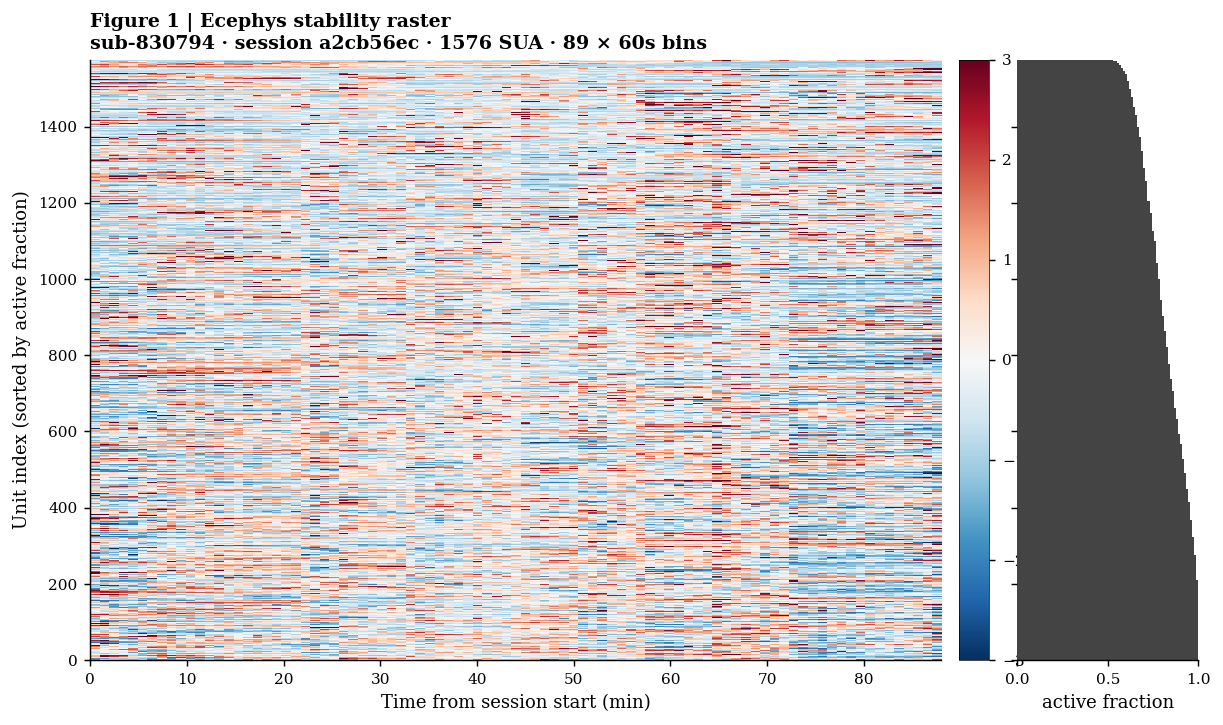

In [7]:
if not eps:
    print("No ecephys cache — skipping Figure 1.")
else:
    # Pick the session with the most units that has a clear gradient in active_frac
    pick = max(eps, key=lambda d: len(d["units"]))
    rates = pick["rates"]
    centers = pick["bin_centers"]
    df = pick["units"]
    order = np.argsort(-df["active_frac"].values)   # most-active first
    rates_s = rates[order, :]
    af_s    = df["active_frac"].values[order]

    z = (rates_s - rates_s.mean(axis=1, keepdims=True)) / np.maximum(
         rates_s.std(axis=1, keepdims=True), 1e-3)
    # Show as image; clip z to ±3
    fig = plt.figure(figsize=(11, 6))
    gs  = GridSpec(1, 2, width_ratios=[5, 1], wspace=0.04, figure=fig)
    ax  = fig.add_subplot(gs[0, 0])
    im  = ax.imshow(np.clip(z, -3, 3), aspect="auto",
                    cmap="RdBu_r", vmin=-3, vmax=3,
                    extent=[(centers[0]-centers[0])/60, (centers[-1]-centers[0])/60,
                            len(rates_s), 0],
                    interpolation="nearest", rasterized=True)
    ax.set_xlabel("Time from session start (min)")
    ax.set_ylabel("Unit index (sorted by active fraction)")
    ax.set_title(f"Figure 1 | Ecephys stability raster\n"
                 f"{pick['subject_id']} · session {pick['asset_id']} · "
                 f"{rates_s.shape[0]} SUA · {rates_s.shape[1]} × {BIN_E_S:.0f}s bins",
                 loc="left", fontweight="bold")
    cb = fig.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    cb.set_label("Within-unit z-scored firing rate")
    cb.outline.set_linewidth(0.4)

    # Right strip: active_frac
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax)
    ax2.barh(np.arange(len(af_s)) + 0.5, af_s, color="#444", height=1.0,
             align="center")
    ax2.set_xlim(0, 1)
    ax2.set_xlabel("active fraction")
    ax2.tick_params(labelleft=False)
    for s in ax2.spines.values(): s.set_visible(False)
    ax2.spines["bottom"].set_visible(True)
    ax2.invert_yaxis()

    fig.savefig("stab_fig1_ecephys_raster.pdf", dpi=150)
    fig.savefig("stab_fig1_ecephys_raster.png")
    plt.show(); plt.close(fig); gc.collect()

## Figure 2 — Ecephys active-unit retention curves

Per session, the count of units exceeding 50 % of their median rate at each time bin, normalised to the value averaged over the first 5 minutes. One curve per session, coloured by subject.

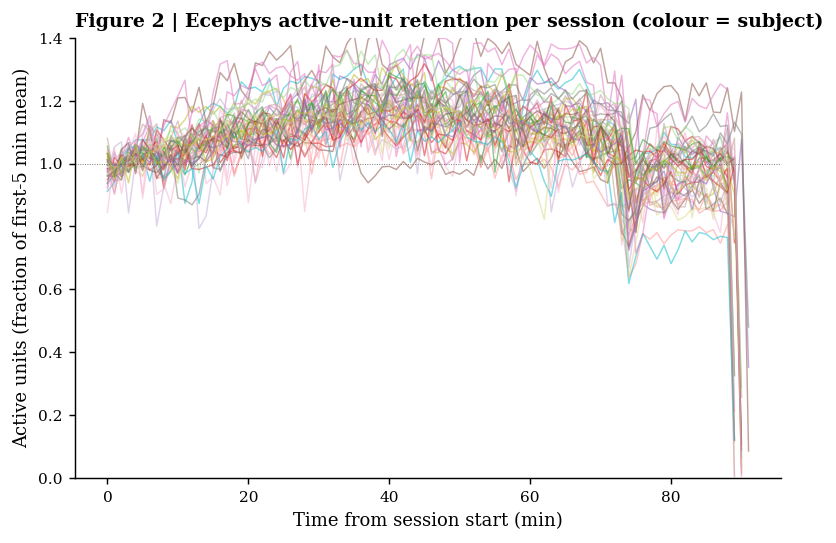

In [8]:
if not eps:
    print("No ecephys cache — skipping Figure 2.")
else:
    fig, ax = plt.subplots(figsize=(7.0, 4.4))
    for d in eps:
        rates = d["rates"]; centers = d["bin_centers"]
        if rates.shape[1] < 6: continue
        med = np.median(rates, axis=1, keepdims=True)
        active = rates >= (ACTIVE_FRAC_RATE_FRAC * np.maximum(med, 0.05))
        n_active = active.sum(axis=0).astype(float)
        # Normalise to mean over first 5 minutes
        t_rel = (centers - centers[0]) / 60.0
        early = t_rel < 5.0
        baseline = n_active[early].mean() if early.any() else n_active[:5].mean()
        if baseline <= 0: continue
        ax.plot(t_rel, n_active / baseline,
                color=SUBJECT_COLOR[d["units"]["subject_id"].iloc[0]],
                lw=0.8, alpha=0.55)
    ax.axhline(1.0, color="0.4", lw=0.5, ls=":")
    ax.set_xlabel("Time from session start (min)")
    ax.set_ylabel("Active units (fraction of first-5 min mean)")
    ax.set_ylim(0, 1.4)
    ax.set_title("Figure 2 | Ecephys active-unit retention per session (colour = subject)",
                 loc="left", fontweight="bold")
    fig.savefig("stab_fig2_ecephys_retention.pdf", dpi=200)
    fig.savefig("stab_fig2_ecephys_retention.png")
    plt.show(); plt.close(fig); gc.collect()

## Figure 3 — Per-unit active-fraction distribution

Density of `active_frac` across all units, all ecephys sessions pooled. A bimodal shape (mass at 1.0 plus a tail towards 0) is the signature of drift — some units are always present, others come and go.

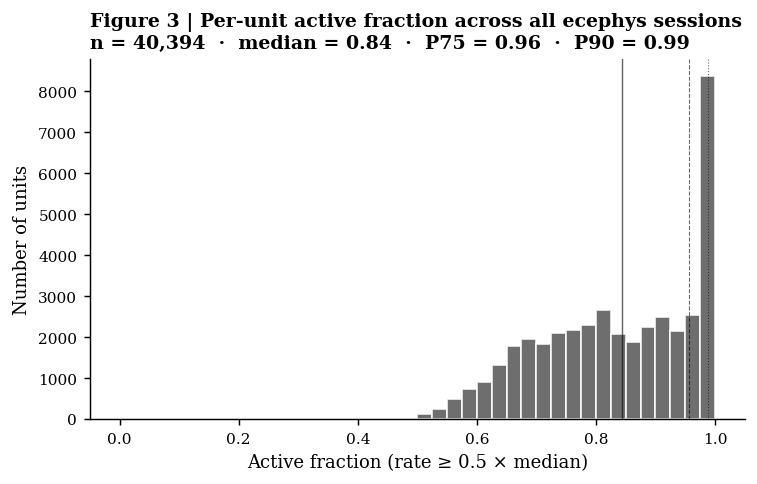

In [9]:
if len(UE) == 0:
    print("No ecephys units — skipping Figure 3.")
else:
    fig, ax = plt.subplots(figsize=(6.5, 3.6))
    bins = np.linspace(0, 1, 41)
    ax.hist(UE["active_frac"].values, bins=bins, color=MOD_COLOR["ecephys"],
            alpha=0.85, edgecolor="white", lw=0.3)
    median = float(np.median(UE["active_frac"]))
    p75   = float(np.percentile(UE["active_frac"], 75))
    p90   = float(np.percentile(UE["active_frac"], 90))
    ax.axvline(median, color="k", lw=0.8, ls="-", alpha=0.6)
    ax.axvline(p75,    color="k", lw=0.6, ls="--", alpha=0.6)
    ax.axvline(p90,    color="k", lw=0.6, ls=":",  alpha=0.6)
    ax.set_xlabel("Active fraction (rate ≥ 0.5 × median)")
    ax.set_ylabel("Number of units")
    ax.set_title(
        f"Figure 3 | Per-unit active fraction across all ecephys sessions\n"
        f"n = {len(UE):,}  ·  median = {median:.2f}  ·  P75 = {p75:.2f}  ·  P90 = {p90:.2f}",
        loc="left", fontweight="bold",
    )
    fig.savefig("stab_fig3_ecephys_active_frac.pdf", dpi=200)
    fig.savefig("stab_fig3_ecephys_active_frac.png")
    plt.show(); plt.close(fig); gc.collect()

## Figure 4 — Mesoscope dF/F SD over time

Per session × plane, the SD of dF/F across ROIs in each 30 s bin, normalised to the first 5 min. Rising SD = shot-noise growth as F decays (photobleaching). Falling SD can mean a z-shift moving cells out of the imaging plane. Mean trajectory across sessions in heavy black.

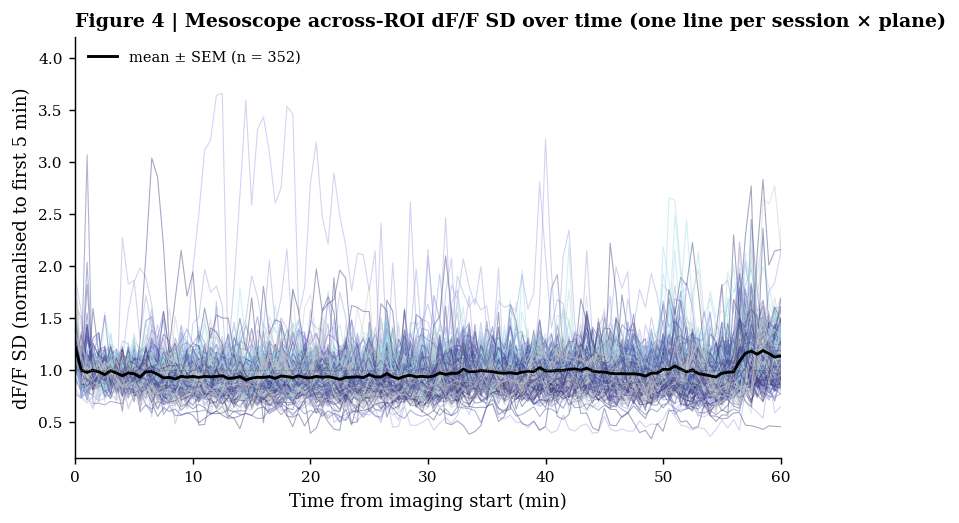

In [10]:
if not MP:
    print("No mesoscope cache — skipping Figure 4.")
else:
    fig, ax = plt.subplots(figsize=(7.0, 4.2))
    common_t = np.linspace(0, 60, 121)   # 0..60 min, 30 s grid
    interp_curves = []
    for r in MP:
        if not np.isfinite(r["std"]).any(): continue
        t_rel = (r["t"] - r["t"][0]) / 60.0
        early = t_rel < 5.0
        if not early.any(): continue
        baseline = float(np.nanmean(r["std"][early]))
        if not np.isfinite(baseline) or baseline <= 0: continue
        norm = r["std"] / baseline
        ax.plot(t_rel, norm,
                color=SUBJECT_COLOR.get(r["subject_id"], "0.5"),
                lw=0.6, alpha=0.45)
        interp = np.interp(common_t, t_rel, norm,
                            left=np.nan, right=np.nan)
        interp_curves.append(interp)
    if interp_curves:
        arr = np.array(interp_curves)
        m   = np.nanmean(arr, axis=0)
        n   = np.sum(np.isfinite(arr), axis=0).clip(1)
        se  = np.nanstd(arr, axis=0) / np.sqrt(n)
        ax.fill_between(common_t, m - se, m + se, color="black", alpha=0.15, lw=0)
        ax.plot(common_t, m, color="black", lw=1.6,
                label=f"mean ± SEM (n = {len(arr)})")
        ax.legend(loc="upper left")
    ax.axhline(1.0, color="0.4", lw=0.5, ls=":")
    ax.set_xlabel("Time from imaging start (min)")
    ax.set_ylabel("dF/F SD (normalised to first 5 min)")
    ax.set_title(
        "Figure 4 | Mesoscope across-ROI dF/F SD over time (one line per session × plane)",
        loc="left", fontweight="bold",
    )
    ax.set_xlim(0, common_t[-1])
    fig.savefig("stab_fig4_meso_snr_over_time.pdf", dpi=200)
    fig.savefig("stab_fig4_meso_snr_over_time.png")
    plt.show(); plt.close(fig); gc.collect()

## Figure 5 — SLAP2 dF/F SD over time per DMD

Same convention as Figure 4 but per DMD. iGluSnFR bleaches faster than GCaMP, so the curves are expected to rise (or fall, if dendrites move out of the patch) more steeply than mesoscope.

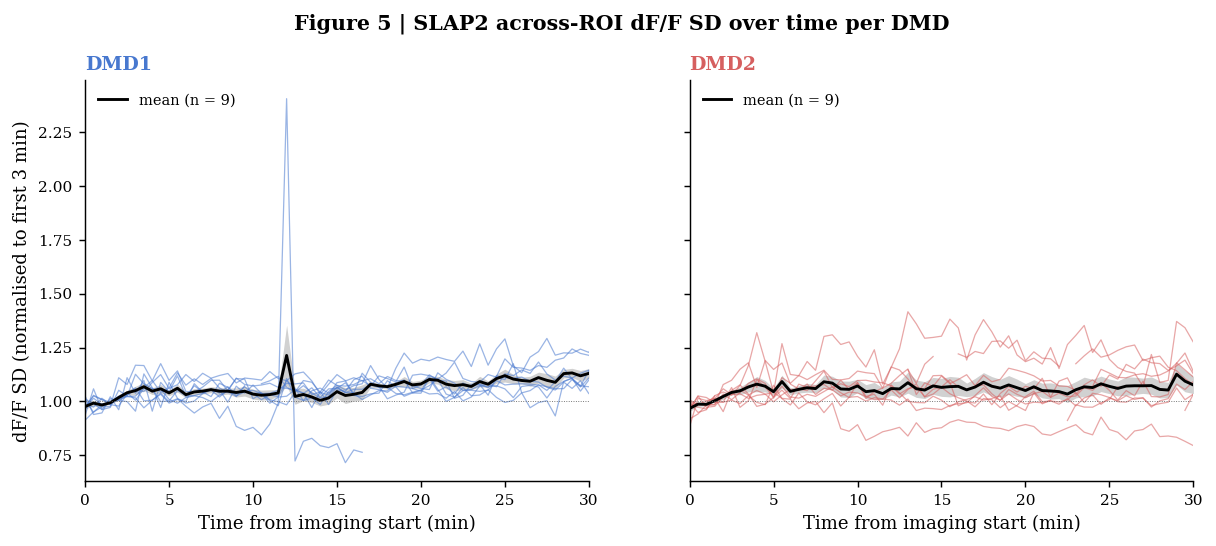

In [11]:
if not SP:
    print("No SLAP2 cache — skipping Figure 5.")
else:
    dmd_color = {"DMD1": "#4878CF", "DMD2": "#D65F5F"}
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharex=True, sharey=True)
    common_t = np.linspace(0, 30, 61)   # SLAP2 sessions are shorter
    for ax_ix, dmd in enumerate(sorted({r["channel"] for r in SP})):
        ax = axes[ax_ix] if ax_ix < len(axes) else axes[-1]
        col = dmd_color.get(dmd, "#555")
        interp_curves = []
        for r in SP:
            if r["channel"] != dmd: continue
            if not np.isfinite(r["std"]).any(): continue
            t_rel = (r["t"] - r["t"][0]) / 60.0
            early = t_rel < 3.0
            if not early.any(): continue
            baseline = float(np.nanmean(r["std"][early]))
            if not np.isfinite(baseline) or baseline <= 0: continue
            norm = r["std"] / baseline
            ax.plot(t_rel, norm, color=col, lw=0.7, alpha=0.55)
            interp_curves.append(np.interp(common_t, t_rel, norm,
                                            left=np.nan, right=np.nan))
        if interp_curves:
            arr = np.array(interp_curves)
            m   = np.nanmean(arr, axis=0)
            n   = np.sum(np.isfinite(arr), axis=0).clip(1)
            se  = np.nanstd(arr, axis=0) / np.sqrt(n)
            ax.fill_between(common_t, m - se, m + se, color="black", alpha=0.18, lw=0)
            ax.plot(common_t, m, color="black", lw=1.6,
                    label=f"mean (n = {len(arr)})")
            ax.legend(loc="upper left")
        ax.axhline(1.0, color="0.4", lw=0.5, ls=":")
        ax.set_xlabel("Time from imaging start (min)")
        ax.set_xlim(0, common_t[-1])
        ax.set_title(dmd, loc="left", fontweight="bold", color=col)
    axes[0].set_ylabel("dF/F SD (normalised to first 3 min)")
    fig.suptitle("Figure 5 | SLAP2 across-ROI dF/F SD over time per DMD",
                 y=1.01, fontweight="bold")
    fig.savefig("stab_fig5_slap2_snr_over_time.pdf", dpi=200)
    fig.savefig("stab_fig5_slap2_snr_over_time.png")
    plt.show(); plt.close(fig); gc.collect()

## Figure 6 — Cross-modal stability summary

One panel per modality, side-by-side, showing the distribution of "signal retained at session end" measured per the modality's natural unit (firing rate retention per ecephys SUA, dF/F SD ratio per mesoscope ROI / SLAP2 ROI). A single number for SNR-over-time degradation that the three modalities can be lined up against.

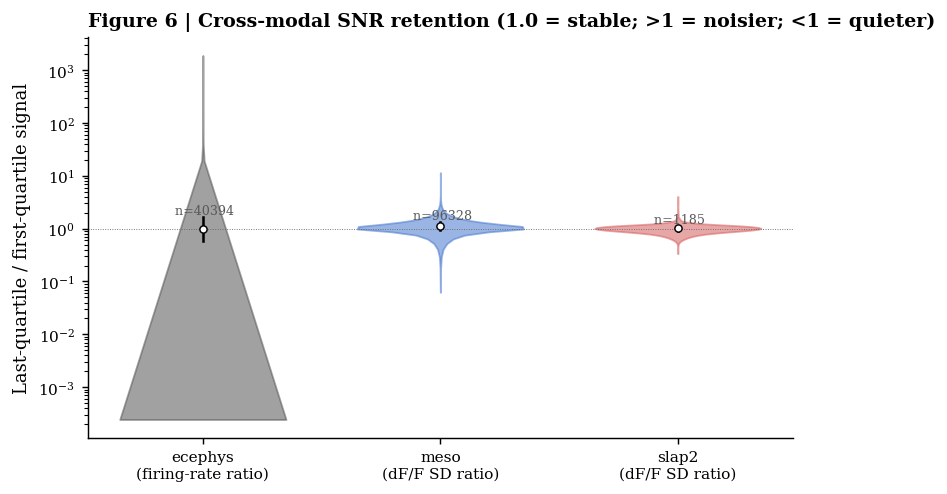

In [12]:
ec_ret = UE["retention"].values if len(UE) else np.array([])
ec_ret = ec_ret[np.isfinite(ec_ret)]

ms_ret = np.concatenate([r["retention"][np.isfinite(r["retention"])]
                          for r in MP if len(r["retention"])]) if MP else np.array([])
sl_ret = np.concatenate([r["retention"][np.isfinite(r["retention"])]
                          for r in SP if len(r["retention"])]) if SP else np.array([])

data = []; labels = []; colors = []; details = []
for name, vals, col, kind in [
    ("ecephys", ec_ret, MOD_COLOR["ecephys"], "firing-rate ratio"),
    ("meso",    ms_ret, MOD_COLOR["meso"],   "dF/F SD ratio"),
    ("slap2",   sl_ret, MOD_COLOR["slap2"],  "dF/F SD ratio"),
]:
    if len(vals) >= 5:
        data.append(vals); labels.append(name); colors.append(col); details.append(kind)

if not data:
    print("Not enough retention data for cross-modal summary.")
else:
    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    pos = np.arange(len(data))
    parts = ax.violinplot(data, positions=pos, widths=0.7,
                          showmeans=False, showmedians=False, showextrema=False)
    for body, c in zip(parts["bodies"], colors):
        body.set_facecolor(c); body.set_edgecolor(c); body.set_alpha(0.55)
    for xi, vals in zip(pos, data):
        q1, med, q3 = np.percentile(vals, [25, 50, 75])
        ax.plot([xi, xi], [q1, q3], color="black", lw=1.4)
        ax.plot(xi, med, "o", color="white", ms=4, mec="black", mew=0.8, zorder=5)
        ax.text(xi, q3, f" n={len(vals)}", fontsize=7, va="bottom", ha="center",
                color="0.35")
    ax.axhline(1.0, color="0.4", lw=0.5, ls=":")
    ax.set_xticks(pos)
    ax.set_xticklabels([f"{l}\n({d})" for l, d in zip(labels, details)])
    ax.set_ylabel("Last-quartile / first-quartile signal")
    ax.set_yscale("log")
    ax.set_title("Figure 6 | Cross-modal SNR retention (1.0 = stable; >1 = noisier; <1 = quieter)",
                 loc="left", fontweight="bold")
    fig.savefig("stab_fig6_cross_modal_summary.pdf", dpi=200)
    fig.savefig("stab_fig6_cross_modal_summary.png")
    plt.show(); plt.close(fig); gc.collect()

---
Caches: `results/stability_cache_ecephys/`, `results/stability_cache_meso/`, `results/stability_cache_slap2/`. Outputs:
* `stab_fig1_ecephys_raster.{pdf,png}`
* `stab_fig2_ecephys_retention.{pdf,png}`
* `stab_fig3_ecephys_active_frac.{pdf,png}`
* `stab_fig4_meso_snr_over_time.{pdf,png}`
* `stab_fig5_slap2_snr_over_time.{pdf,png}`
* `stab_fig6_cross_modal_summary.{pdf,png}`